# DAG-DTW matching playground

**Match a whole source DAG (several A-edges forming branches / merges) to a directed B-network,
in one joint solve — and see which A-part maps to which B-edge.**

Where the graph-DTW playground matches ONE A-edge, this matches a **topologically-ordered,
acyclic set of A-edges** (a junction neighbourhood) jointly, so edges meeting at a junction map to
a **consistent** place in B. Every A-vertex shows a link to its matched B-vertex `φ(a)`, coloured
by the B-edge it lands on; branch/merge junctions are ringed. No analysis panels.

Algorithm spec: [`docs/dag_dtw_matching.md`](../docs/dag_dtw_matching.md). This is the
**point-to-point v1**. Kernel: `network-matching` (needs `ipywidgets`).

In [1]:
# Setup (run once) -- code lives in network_matching/dag_*.py; %autoreload picks up changes.
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt

from network_matching.dag_dtw import match_dag_to_bgraph
from network_matching.dag_synthetic import DAG_SCENARIOS, get_dag, list_dags
from network_matching.dag_playground import (DAG_PLAYGROUND_VERSION, draw_dag_match,
                                             match_and_draw_dag, perturb_dag, dag_playground)

print("DAG playground:", DAG_PLAYGROUND_VERSION)
print("built-in DAGs:", ", ".join(list_dags()))

DAG playground: v2 -- correspondence view that CHECKS the sequence rules (flags backward / jump / disconnected in the title + red arcs)
built-in DAGs: chain, diamond, merge, y_split


## Static example — a Y-split

One corridor that **branches** into two exits at a junction, over a B-network that branches the
same way. `A_main` is matched once; both exits agree the split happens at the same B-vertex (the
red **branch junction** ring). Each A-vertex's link is coloured by the B-edge it maps to.

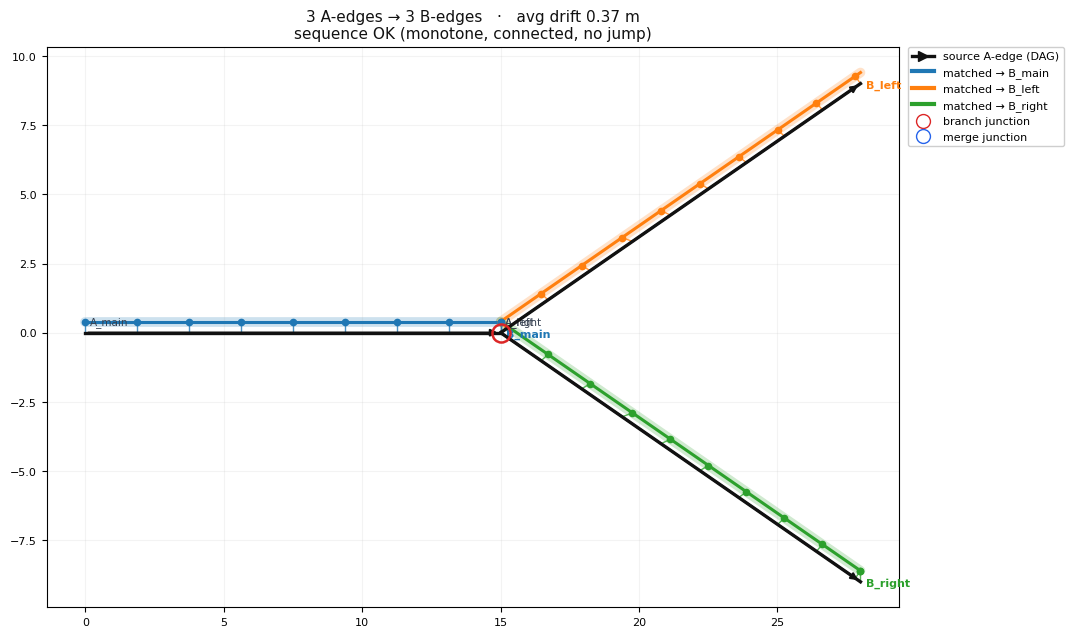

routes: {'A_main': ['B_main'], 'A_left': ['B_left'], 'A_right': ['B_right']}
avg drift 0.37 m   total cost 11.63   (sources 1, sinks 2)


In [2]:
sc = get_dag("y_split")
res = match_and_draw_dag(sc["a_edges"], sc["b_edges"], **sc["defaults"])
print("routes:", {k: v for k, v in res["routes"].items()})
print(f"avg drift {res['avg_drift']:.2f} m   total cost {res['total_cost']:.2f}"
      f"   (sources {len(res['sources'])}, sinks {len(res['sinks'])})")

## The four built-in DAG test cases

The debug ladder from the spec (§4): `chain` (one path — must behave like graph-DTW), `y_split`
(a branch), `merge` (two approaches join), `diamond` (split **and** re-merge — exercises the
`1/outdeg` conserved-flow split factor).

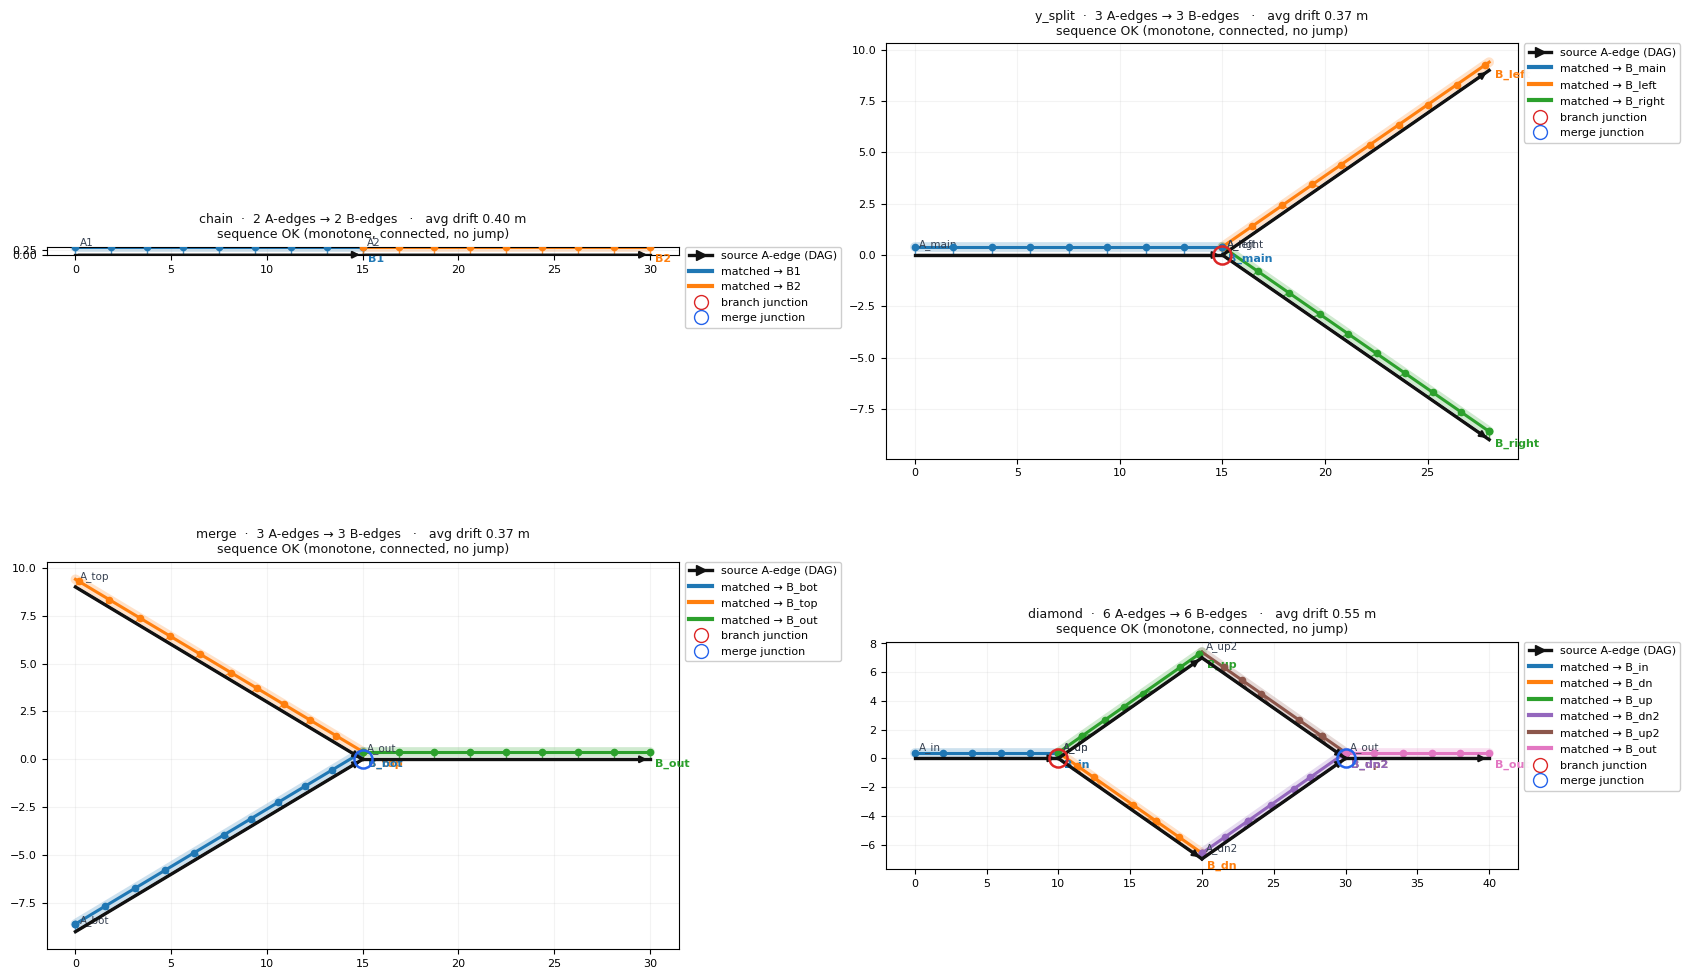

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
for ax, name in zip(axes.ravel(), ["chain", "y_split", "merge", "diamond"]):
    sc = get_dag(name)
    match_and_draw_dag(sc["a_edges"], sc["b_edges"], ax=ax, **sc["defaults"])
    ax.set_title(name + "  ·  " + ax.get_title(), fontsize=9)
plt.tight_layout()
plt.show()

## Interactive playground

Pick a DAG and move the **whole** source rigidly (shift / rotate) or jitter it (noise) — junctions
stay stitched, so the DAG topology is preserved — and watch the joint match update. `sample m` is
the point-pool density (`step_meters`).

In [4]:
dag_playground()

Output()

## Build your own DAG — and drive it with the sliders

A source DAG is just a set of directed A-edges that **stitch at shared endpoints** (predecessors
before successors, no loop). Edit `my_a` / `my_b` below — add an edge with one
`("id", [(x, y), ...])` line, keeping an endpoint shared with another edge to connect it — then
`dag_playground(my_a, my_b)` gives you the **same interactive sliders on your own DAG** (the whole
source moves rigidly, so junctions stay stitched).

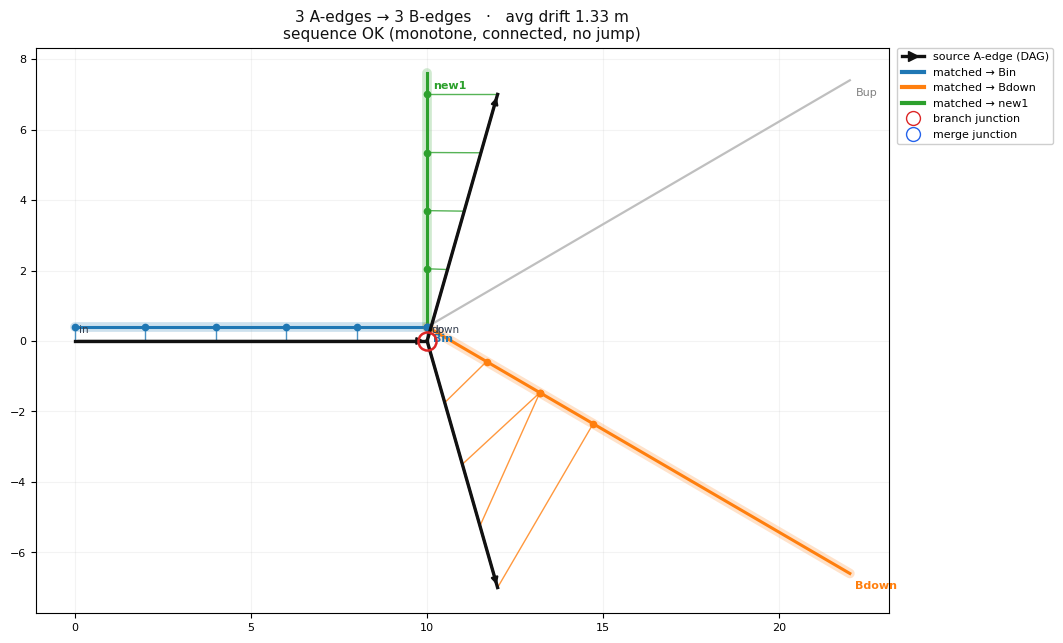

routes: {'in': ['Bin'], 'down': ['Bdown'], 'up': ['Bin', 'new1']}


Output()

In [5]:
my_a = [
    ("in",    [(0, 0), (10, 0)]),          # main corridor in...
    ("up",    [(10, 0), (12, 7)]),         # ...branches up
    ("down",  [(10, 0), (12, -7)]),        # ...and down   (a Y-split at (10,0))
    # ("up2", [(22, 7), (34, 7)]),         # <- extend a branch like this
]
my_b = [
    ("Bin",   [(0, 0.4), (10, 0.4)]),
    ("Bup",   [(10, 0.4), (22, 7.4)]),
    ("Bdown", [(10, 0.4), (22, -6.6)]),
    ("new1", [(10, 0.4), (10, 7.6)]),
]

# static view once...
res = match_and_draw_dag(my_a, my_b)
print("routes:", dict(res["routes"]))

# ...then interactive: same sliders, on YOUR dag
dag_playground(my_a, my_b)

### Scripted perturbation of your DAG

The DAG version of `perturb_edge` is **`perturb_dag`** — it moves the *whole* source rigidly so
junctions stay stitched (`shift` / `rotate` / `noise`; no `stretch`/`crop`, which would break a
junction). Then match + draw with `match_and_draw_dag` (no `to_edges` needed).

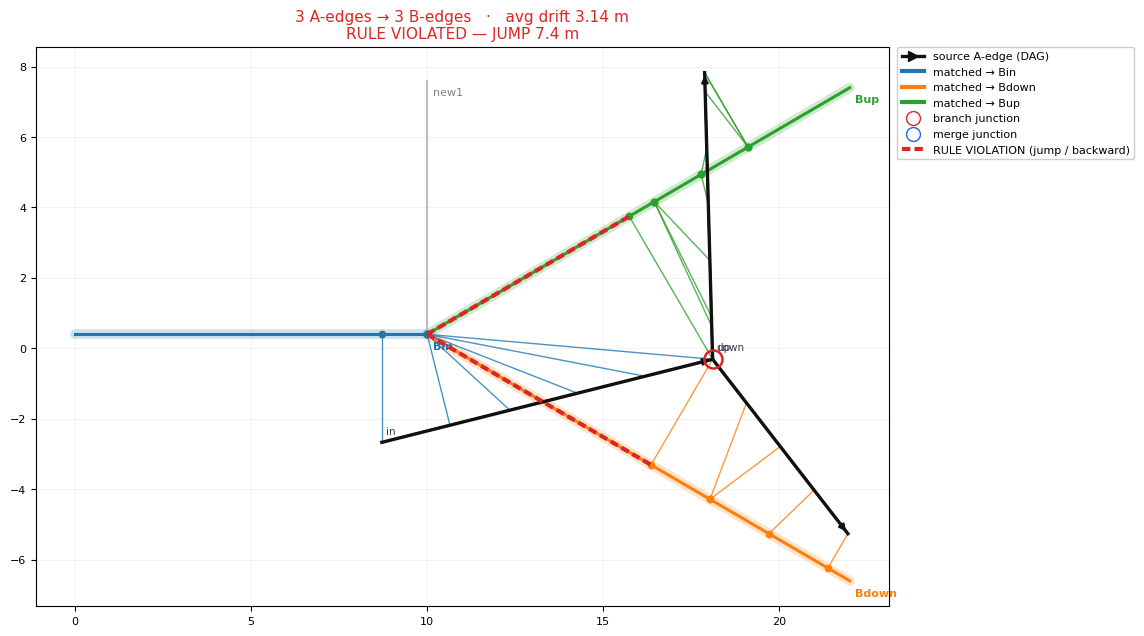

routes: {'in': ['Bin'], 'down': ['Bdown'], 'up': ['Bup']}  avg drift 3.14 m


In [6]:
A = perturb_dag(my_a, shift=8, rotate=20, noise=0.5, seed=1)   # move the whole DAG rigidly
res = match_and_draw_dag(A, my_b)
print("routes:", dict(res["routes"]), " avg drift %.2f m" % res["avg_drift"])

---
**How to read it.** Black arrows = the source A-edges (the DAG); grey = candidate B-edges;
coloured B-edges = matched, each A-vertex linked to its `φ(a)` in that colour. **Red ring** = a
branch junction (out-degree > 1), **blue ring** = a merge junction (in-degree > 1). The title
reports the average drift (meters) — the DAG is matched **jointly**, so the junctions are
consistent by construction.

The algorithm (one joint DP: three DTW moves, sum-over-branches with the `1/outdeg` split factor,
topological sweep, Dijkstra over B) is in `network_matching/dag_dtw.py`; the spec, including the
optimization plan, is in `docs/dag_dtw_matching.md`.